# **Import The Libraries** 📕 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Read The Data** 📥 

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/ahmedhamdyshh/social-media-addiction")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/ahmedhamdyshh/social-media-addiction


100%|██████████| 12.2k/12.2k [00:00<00:00, 23.3MB/s]

In [4]:
import os

print(os.listdir("social-media-addiction"))

['Social_Media_Addiction.csv']


In [5]:
df = pd.read_csv("social-media-addiction/Social_Media_Addiction.csv")

# **Exploratory Data Analysis (EDA)** 🌍

In [6]:
df.shape

(481, 24)

In [7]:
df.head().T

,0,1,2,3,4
Timestamp,4/18/2022 19:18:47,4/18/2022 19:19:28,4/18/2022 19:25:59,4/18/2022 19:29:43,4/18/2022 19:33:31
1. What is your age?,21.0,21.0,21.0,21.0,21.0
2. Gender,Male,Female,Female,Female,Female
3. Relationship Status,In a relationship,Single,Single,Single,Single
4. Occupation Status,University Student,University Student,University Student,University Student,University Student
5. What type of organizations are you affiliated with?,University,University,University,University,University
6. Do you use social media?,Yes,Yes,Yes,Yes,Yes
7. What social media platforms do you commonly use?,"Facebook, Twitter, Instagram, YouTube, Discord...","Facebook, Twitter, Instagram, YouTube, Discord...","Facebook, Instagram, YouTube, Pinterest","Facebook, Instagram","Facebook, Instagram, YouTube"
8. What is the average time you spend on social media every day?,Between 2 and 3 hours,More than 5 hours,Between 3 and 4 hours,More than 5 hours,Between 2 and 3 hours
9. How often do you find yourself using Social media without a specific purpose?,5,4,3,4,3


In [8]:
new_col_names = {
    'Timestamp': 'timestamp',
    '1. What is your age?': 'age',
    '2. Gender': 'gender',
    '3. Relationship Status': 'relationship_status',
    '4. Occupation Status': 'occupation_status',
    '5. What type of organizations are you affiliated with?': 'affiliate_organization',
    '6. Do you use social media?': 'social_media_use',
    '7. What social media platforms do you commonly use?': 'platforms',
    '8. What is the average time you spend on social media every day?': 'avg_time_per_day',
    '9. How often do you find yourself using Social media without a specific purpose?': 'use_without_purpose(1-5)',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'distracted(1-5)',
    "11. Do you feel restless if you haven't used Social media in a while?": 'restless(1-5)',
    '12. On a scale of 1 to 5, how easily distracted are you?' : 'distracted_easily(1-5)',
    '13. On a scale of 1 to 5, how much are you bothered by worries?' : 'worries(1-5)',
    '14. Do you find it difficult to concentrate on things?' : 'concentration(1-5)',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?' : 'compare_to_others(1-5)',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?' : 'compare_feelings(1-5)',
    '17. How often do you look to seek validation from features of social media?' : 'validation(1-5)',
    '18. How often do you feel depressed or down?' : 'depressed(1-5)',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?' : 'daily_activity_fluctuate(1-5)',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?' : 'sleeping_issues(1-5)',
}

df.rename(columns=new_col_names, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   timestamp                      481 non-null    object 
 1   age                            481 non-null    float64
 2   gender                         481 non-null    object 
 3   relationship_status            481 non-null    object 
 4   occupation_status              481 non-null    object 
 5   affiliate_organization         451 non-null    object 
 6   social_media_use               481 non-null    object 
 7   platforms                      481 non-null    object 
 8   avg_time_per_day               481 non-null    object 
 9   use_without_purpose(1-5)       481 non-null    int64  
 10  distracted(1-5)                481 non-null    int64  
 11  restless(1-5)                  481 non-null    int64  
 12  distracted_easily(1-5)         481 non-null    int

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,481.0,26.136590,9.915110,13.0,21.00,22.00,26.00,91.0
use_without_purpose(1-5),481.0,3.553015,1.096299,1.0,3.00,4.00,4.00,5.0
distracted(1-5),481.0,3.320166,1.328137,1.0,2.00,3.00,4.00,5.0
restless(1-5),481.0,2.588358,1.257059,1.0,2.00,2.00,3.00,5.0
distracted_easily(1-5),481.0,3.349272,1.175552,1.0,3.00,3.00,4.00,5.0
worries(1-5),481.0,3.559252,1.283356,1.0,3.00,4.00,5.00,5.0
concentration(1-5),481.0,3.245322,1.347105,1.0,2.00,3.00,4.00,5.0
compare_to_others(1-5),481.0,2.831601,1.407835,1.0,2.00,3.00,4.00,5.0
compare_feelings(1-5),481.0,2.775468,1.056479,1.0,2.00,3.00,3.00,5.0
validation(1-5),481.0,2.455301,1.247739,1.0,1.00,2.00,3.00,5.0


In [11]:
df['gender'].value_counts()

,count
gender,
Female,263
Male,211
Nonbinary,1
Non-binary,1
NB,1
unsure,1
Trans,1
Non binary,1
There are others???,1


write
a note 
after 
each 
cell

In [12]:
df['relationship_status'].value_counts()

,count
relationship_status,
Single,285
Married,101
In a relationship,88
Divorced,7


In [13]:
df['occupation_status'].value_counts()

,count
occupation_status,
University Student,292
Salaried Worker,132
School Student,49
Retired,8


In [14]:
df['affiliate_organization'].value_counts()

,count
affiliate_organization,
University,239
Private,60
School,44
Company,30
"University, Company",19
"University, Private",16
"School, University",9
"Company, Private",7
Goverment,6


In [15]:
df['platforms'].value_counts()

,count
platforms,
"Facebook, Instagram, YouTube",35
"Facebook, YouTube",30
"Facebook, Instagram, YouTube, Snapchat",28
"Facebook, Instagram, YouTube, Snapchat, Discord",19
"Facebook, Instagram, YouTube, Discord",18
...,...
"Facebook, Instagram, YouTube, Reddit, TikTok",1
"Facebook, Twitter, YouTube, Pinterest",1
"Instagram, Discord",1


In [16]:
df['social_media_use'].value_counts()

,count
social_media_use,
Yes,478
No,3


In [17]:
df['avg_time_per_day'].value_counts()

,count
avg_time_per_day,
More than 5 hours,116
Between 2 and 3 hours,101
Between 3 and 4 hours,93
Between 1 and 2 hours,70
Between 4 and 5 hours,67
Less than an Hour,34


# **Data Cleaning** 🧼

In [18]:
df.drop(columns=['timestamp', 'social_media_use'], inplace=True)

In [19]:
def gender_map(value):
    if str(value).strip().lower() == 'female':
        return 'Female'
    return 'Male'

df['gender'] = df['gender'].apply(gender_map)
df['gender'].value_counts()

,count
gender,
Female,263
Male,218


In [20]:
def count_affiliations(value):
    if pd.isna(value):
        return 0
    
    parts = str(value).split(',')
    counts = 0
    for p in parts:
        p = p.strip().lower()
        if p != 'n/a' and p != '':
            counts += 1
    return counts

df['affiliate_organization'] = df['affiliate_organization'].apply(count_affiliations)
df['affiliate_organization'].value_counts()

,count
affiliate_organization,
1,384
2,56
0,30
3,11


In [21]:
def count_platforms(value):
    if pd.isna(value):
        return 0
    
    parts = str(value).split(',')
    counts = 0
    for p in parts:
        p = p.strip().lower()
        if p != 'n/a' and p != '':
            counts += 1
    return counts

df['platforms'] = df['platforms'].apply(count_platforms)
df['platforms'].value_counts()

,count
platforms,
4,103
3,79
5,77
2,59
6,52
7,44
1,38
8,18
9,11


### **Action(1): Handle Missing Values (Imputation)**


In [22]:
df.isna().sum()

,0
age,0
gender,0
relationship_status,0
occupation_status,0
affiliate_organization,0
platforms,0
avg_time_per_day,0
use_without_purpose(1-5),0
distracted(1-5),0
restless(1-5),0


### **Action(2): Handle Duplicated Values**

In [23]:
df.duplicated().sum()

np.int64(0)

# **Data Visualization** 📊


/tmp/ipykernel_649/2741803389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='Set2')


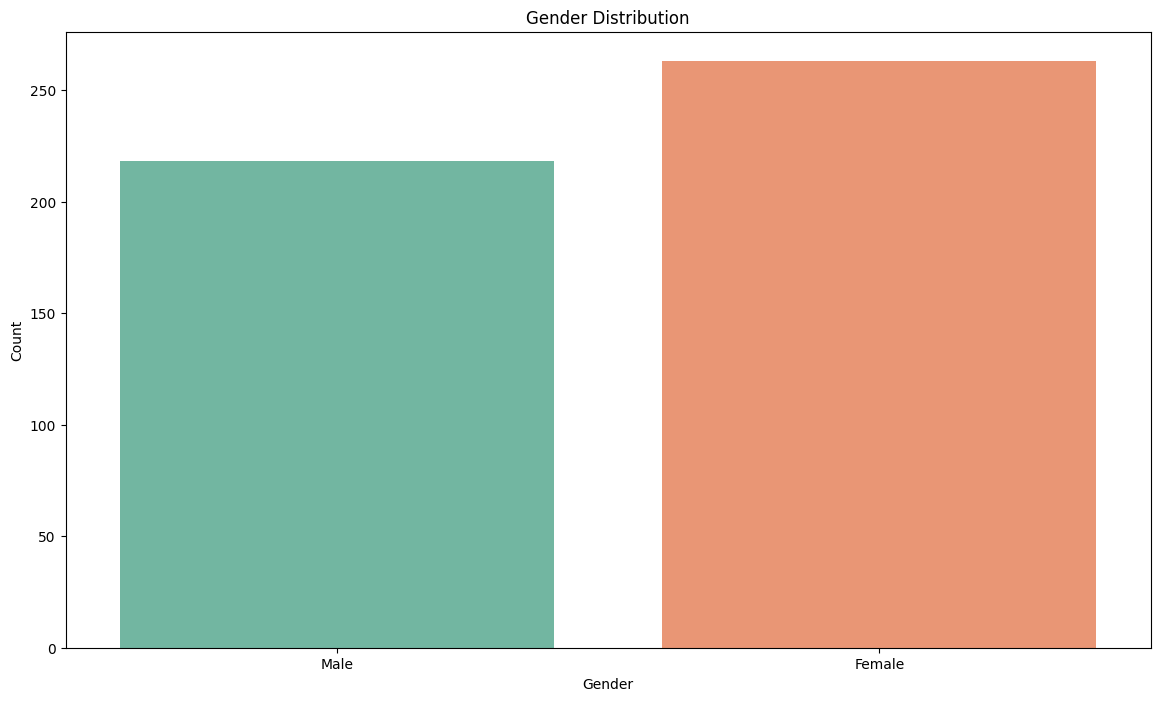

In [24]:
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='gender', palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

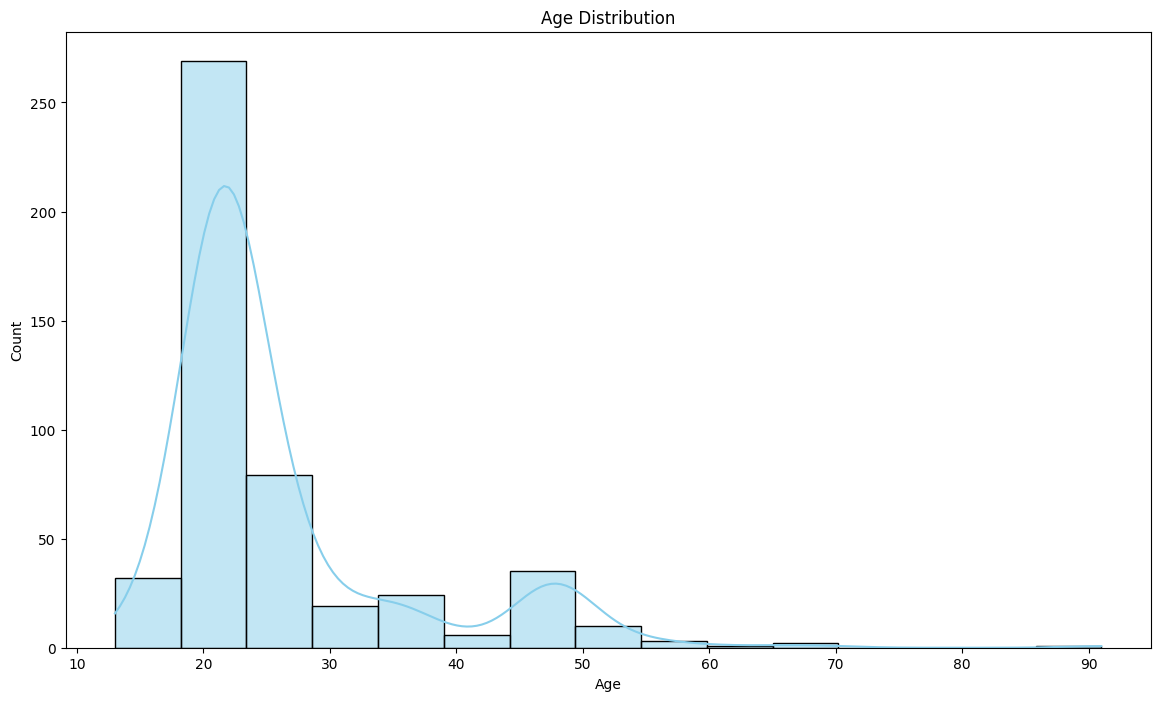

In [25]:
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='age', bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


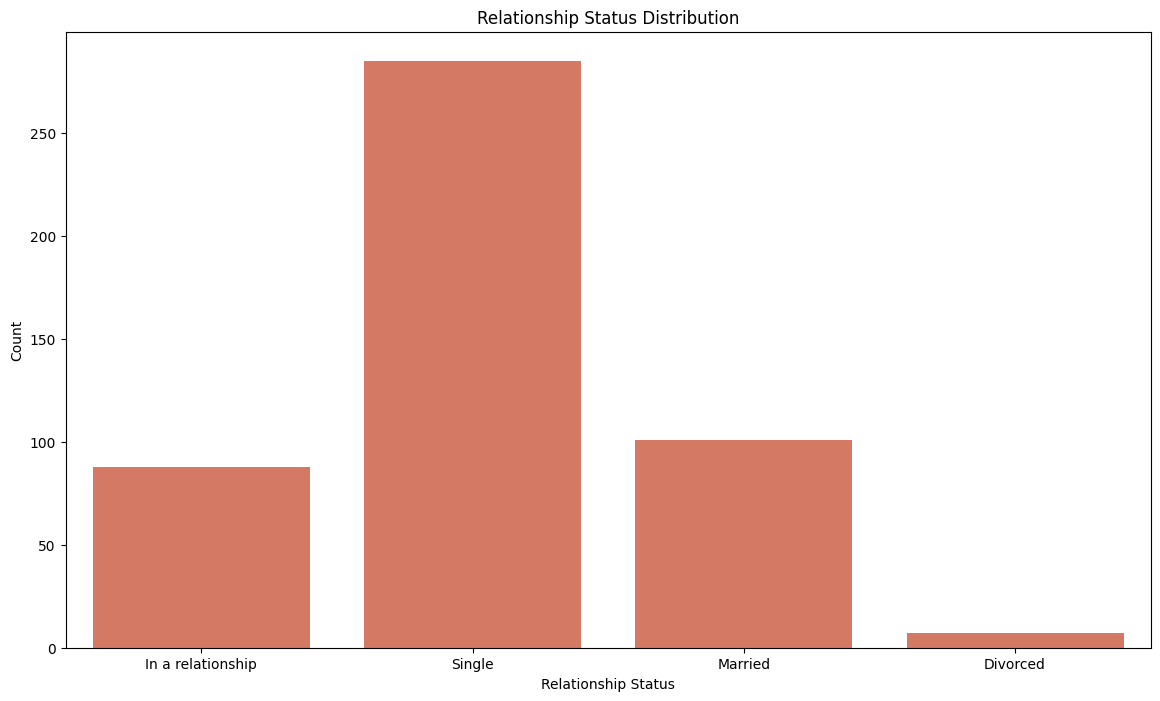

In [26]:
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='relationship_status', color='#e76f51')
plt.title('Relationship Status Distribution')
plt.xlabel('Relationship Status')
plt.ylabel('Count')
plt.show()

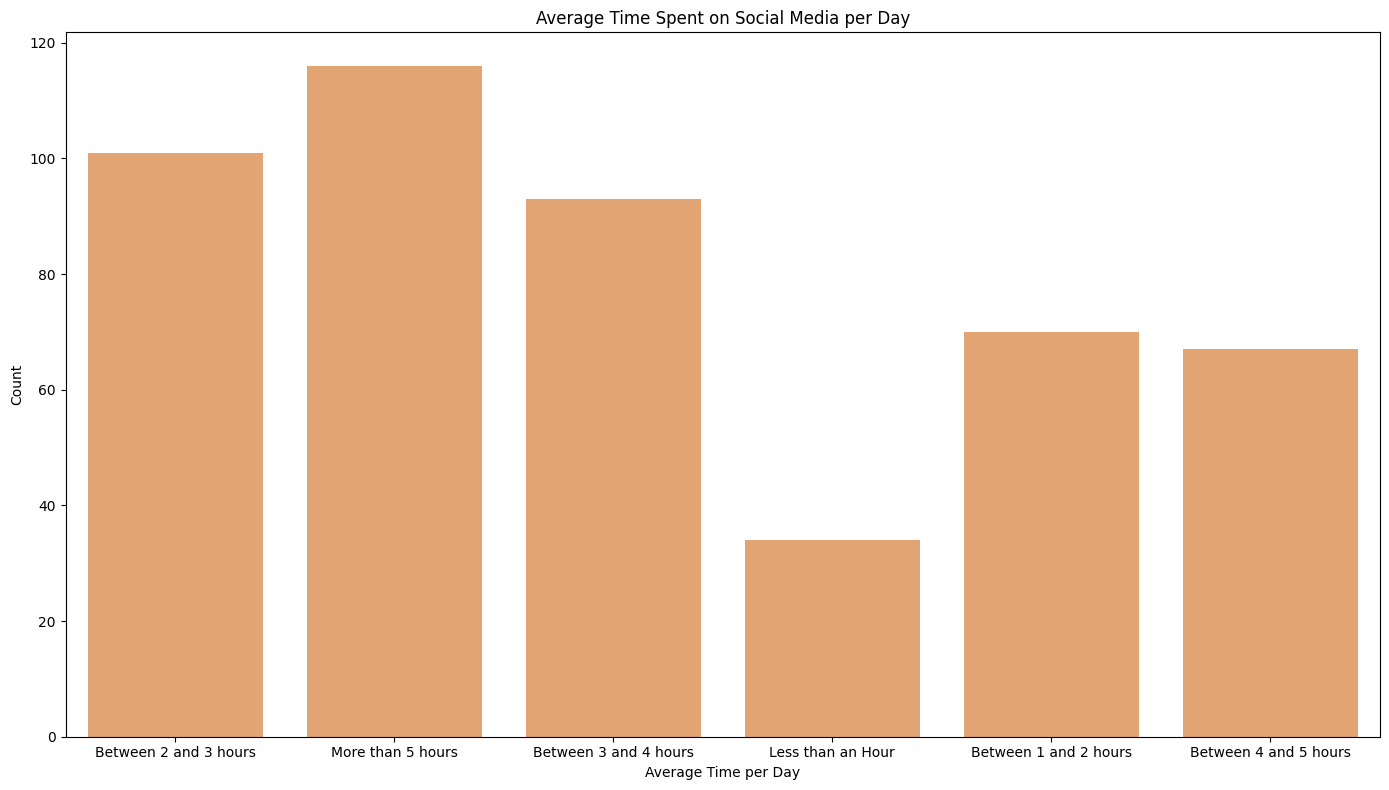

In [27]:
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='avg_time_per_day', color='#f4a261')
plt.title('Average Time Spent on Social Media per Day')
plt.xlabel('Average Time per Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

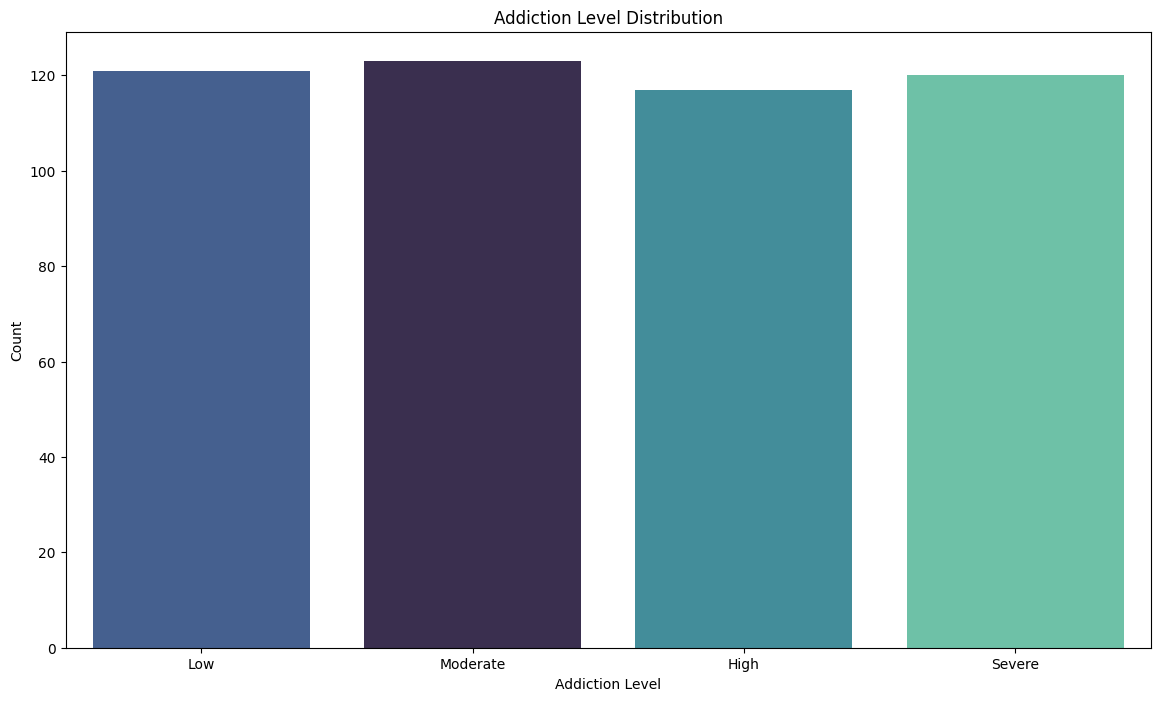

In [28]:
plt.figure(figsize=(14, 8))
sns.countplot(x="Addiction_Level", data=df, order=["Low","Moderate","High","Severe"],
              hue="Addiction_Level", palette="mako", legend=False)
plt.title('Addiction Level Distribution')
plt.xlabel('Addiction Level')
plt.ylabel('Count')
plt.show()


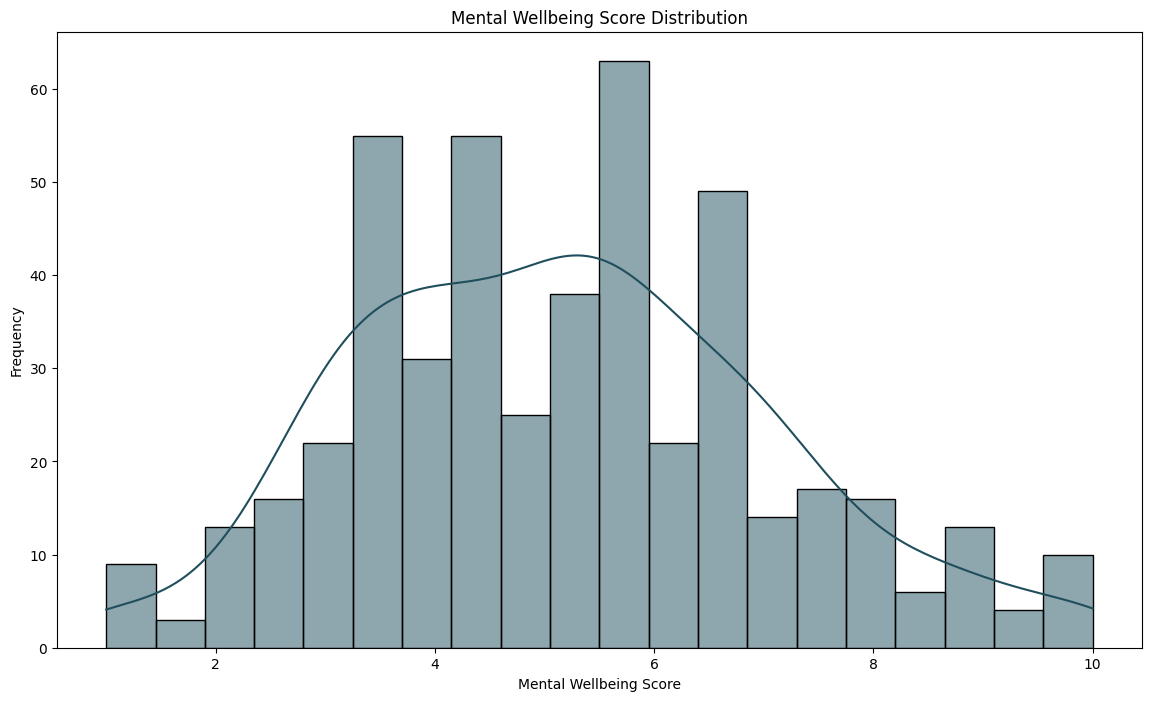

In [29]:
plt.figure(figsize=(14, 8))
sns.histplot(df["Mental_Wellbeing_Score"], bins=20, kde=True, color="#1f4e5c")
plt.title('Mental Wellbeing Score Distribution')
plt.xlabel('Mental Wellbeing Score')
plt.ylabel('Frequency')
plt.show()


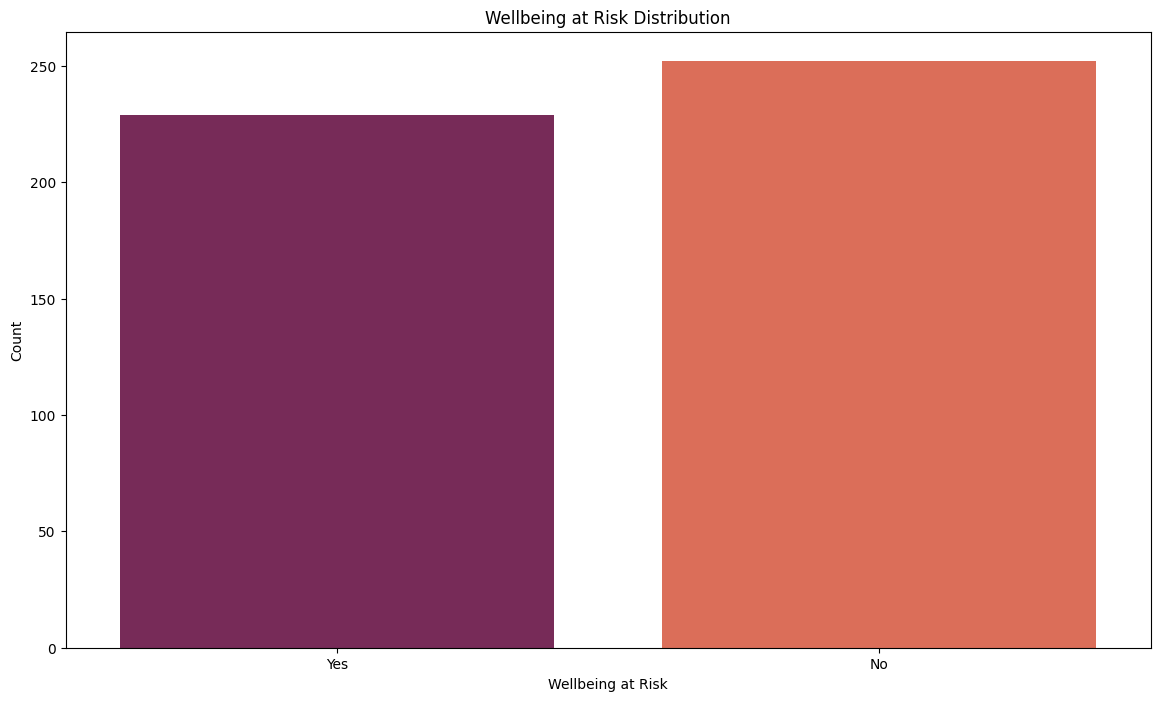

In [30]:
plt.figure(figsize=(14, 8))
sns.countplot(x="Wellbeing_At_Risk", data=df, hue="Wellbeing_At_Risk", palette="rocket",
              legend=False)
plt.title('Wellbeing at Risk Distribution')
plt.xlabel('Wellbeing at Risk')
plt.ylabel('Count')
plt.show()

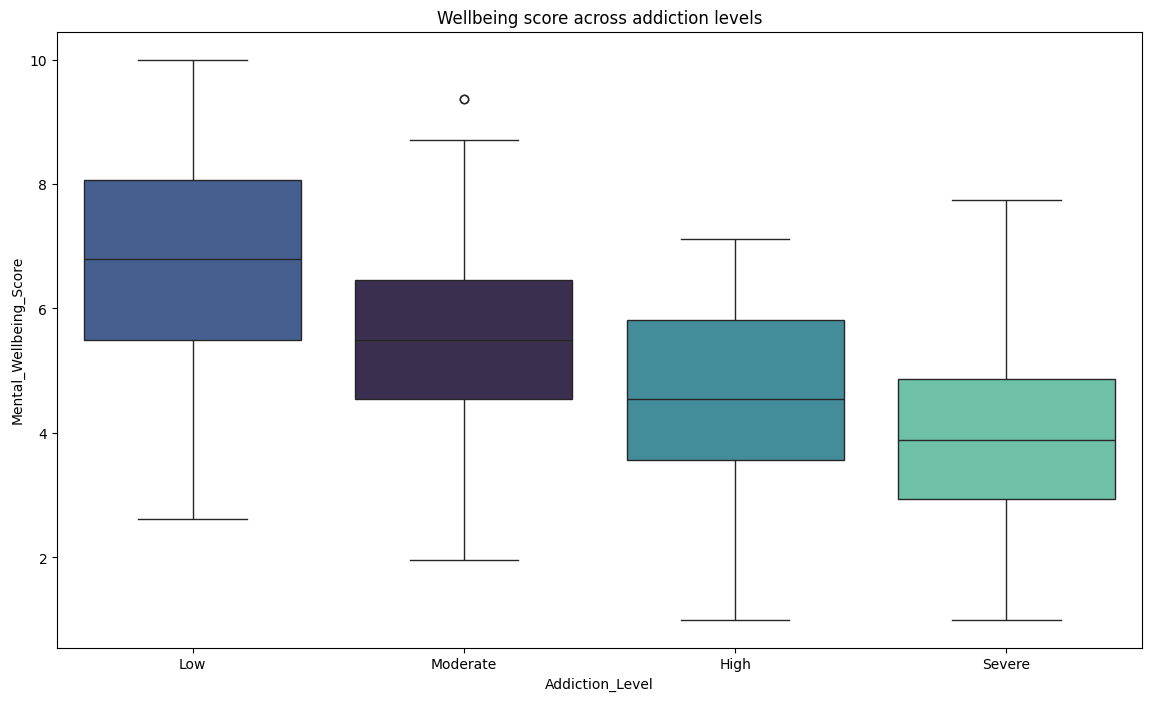

In [31]:
plt.figure(figsize=(14, 8))
sns.boxplot(x="Addiction_Level", y="Mental_Wellbeing_Score", data=df,
            order=["Low","Moderate","High","Severe"], hue="Addiction_Level",
            palette="mako", legend=False)
plt.title("Wellbeing score across addiction levels")
plt.show()

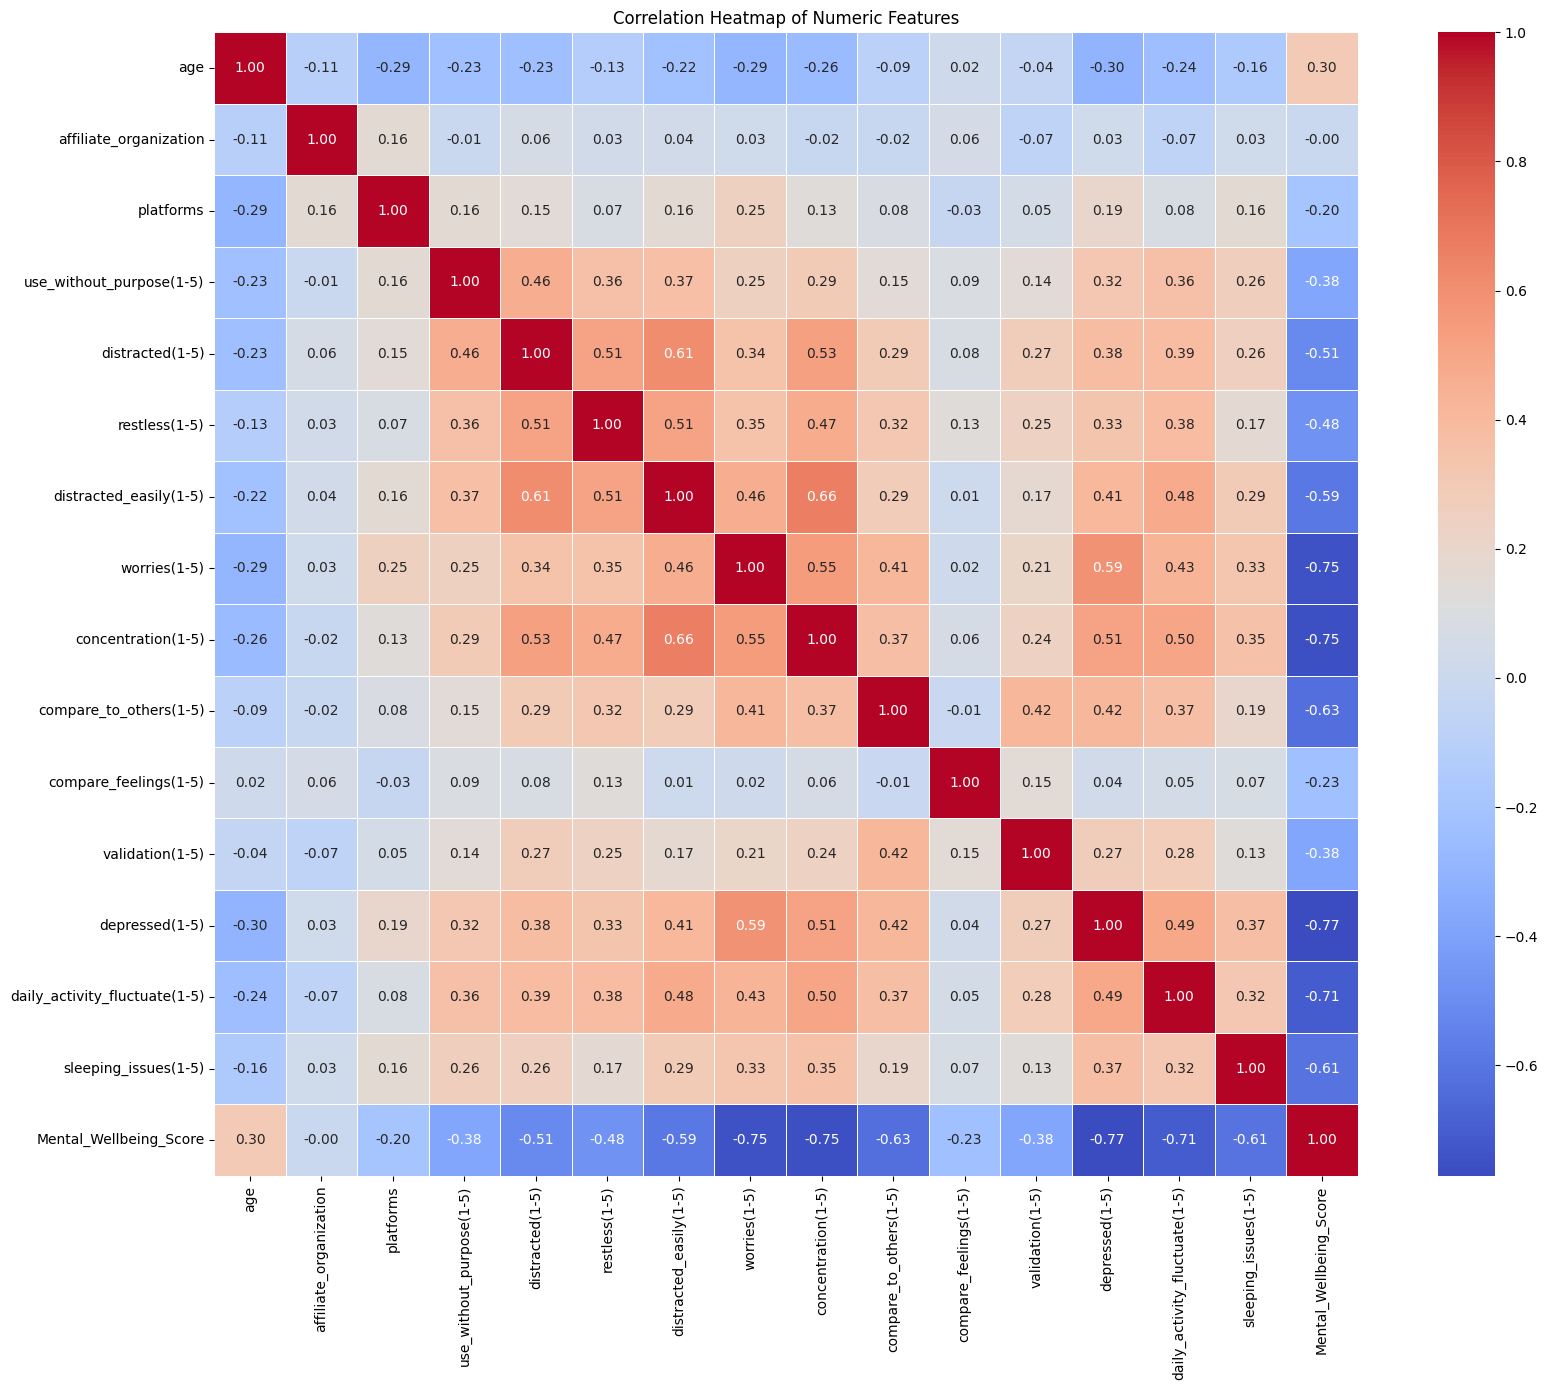

In [32]:
numeric_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(18, 14))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

# **Data Preprocessing & Feature Engineering** 🚀 


### **Action(1): Handling Categorical Data**


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            481 non-null    float64
 1   gender                         481 non-null    object 
 2   relationship_status            481 non-null    object 
 3   occupation_status              481 non-null    object 
 4   affiliate_organization         481 non-null    int64  
 5   platforms                      481 non-null    int64  
 6   avg_time_per_day               481 non-null    object 
 7   use_without_purpose(1-5)       481 non-null    int64  
 8   distracted(1-5)                481 non-null    int64  
 9   restless(1-5)                  481 non-null    int64  
 10  distracted_easily(1-5)         481 non-null    int64  
 11  worries(1-5)                   481 non-null    int64  
 12  concentration(1-5)             481 non-null    int

In [34]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

In [35]:
df = pd.get_dummies(df, columns=['relationship_status', 'occupation_status'], drop_first=True,dtype=int)

In [36]:
from sklearn.preprocessing import OrdinalEncoder

order = [['Less than an Hour', 'Between 1 and 2 hours', 'Between 2 and 3 hours',
          'Between 3 and 4 hours', 'Between 4 and 5 hours', 'More than 5 hours']]

encoder_avg_time = OrdinalEncoder(categories=order)
df['avg_time_per_day'] = encoder_avg_time.fit_transform(df[['avg_time_per_day']])

In [37]:
addiction_levels = ["Low", "Moderate", "High", "Severe"]

encoder_addiction = OrdinalEncoder(categories=[addiction_levels])
df['Addiction_Level'] = encoder_addiction.fit_transform(df[['Addiction_Level']])

In [38]:
le_risk = LabelEncoder()
df['Wellbeing_At_Risk'] = le_risk.fit_transform(df['Wellbeing_At_Risk'])

In [39]:
df.head()

,age,gender,affiliate_organization,platforms,avg_time_per_day,use_without_purpose(1-5),distracted(1-5),restless(1-5),distracted_easily(1-5),worries(1-5),...,sleeping_issues(1-5),Addiction_Level,Mental_Wellbeing_Score,Wellbeing_At_Risk,relationship_status_In a relationship,relationship_status_Married,relationship_status_Single,occupation_status_Salaried Worker,occupation_status_School Student,occupation_status_University Student
0,21.0,1,1,6,2.0,5,3,2,5,2,...,5,1.0,3.89,1,1,0,0,0,0,1
1,21.0,0,1,6,5.0,4,3,2,4,5,...,5,1.0,2.93,1,0,0,1,0,0,1
2,21.0,0,1,4,3.0,3,2,1,2,5,...,5,0.0,3.89,1,0,0,1,0,0,1
3,21.0,0,1,2,5.0,4,2,1,3,5,...,2,1.0,4.86,1,0,0,1,0,0,1
4,21.0,0,1,3,2.0,3,5,4,4,5,...,1,2.0,4.21,1,0,0,1,0,0,1


# **Split the data** ✂️

In [40]:
from sklearn.model_selection import train_test_split

targets = ['Addiction_Level', 'Mental_Wellbeing_Score', 'Wellbeing_At_Risk']

X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Action(2): Handling Numerical Data**

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Training & Evaluation** 🤖


### **Addiction Level**

##### **(i) LogisticRegression**

In [42]:
from sklearn.linear_model import LogisticRegression

y_train_addiction = y_train['Addiction_Level']
y_test_addiction = y_test['Addiction_Level']

lr_addiction = LogisticRegression(C=10)
lr_addiction.fit(X_train_scaled, y_train_addiction)

LogisticRegression(C=10)

In [43]:
y_pred_addiction = lr_addiction.predict(X_test_scaled)

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

acc_lr_addiction = accuracy_score(y_test_addiction, y_pred_addiction)
cm_lr_addiction = confusion_matrix(y_test_addiction, y_pred_addiction)
precision_lr_addiction = precision_score(y_test_addiction, y_pred_addiction, average='weighted')
recall_lr_addiction = recall_score(y_test_addiction, y_pred_addiction, average='weighted')
f1_lr_addiction = f1_score(y_test_addiction, y_pred_addiction, average='weighted')

In [45]:
results_addiction = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f"{acc_lr_addiction * 100:.2f}%", f"{precision_lr_addiction * 100:.2f}%", f"{recall_lr_addiction * 100:.2f}%", f"{f1_lr_addiction * 100:.2f}%"]
})

results_addiction

,Metric,Score
0,Accuracy,90.72%
1,Precision,91.31%
2,Recall,90.72%
3,F1 Score,90.76%


##### **(ii) KNeighborsClassifier**

In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn_addiction = KNeighborsClassifier(n_neighbors=15, weights='distance', p=1)
knn_addiction.fit(X_train_scaled, y_train_addiction)

KNeighborsClassifier(n_neighbors=15, p=1, weights='distance')

In [47]:
y_pred_knn_addiction = knn_addiction.predict(X_test_scaled)

In [48]:
acc_knn_addiction = accuracy_score(y_test_addiction, y_pred_knn_addiction)
cm_knn_addiction = confusion_matrix(y_test_addiction, y_pred_knn_addiction)
precision_knn_addiction = precision_score(y_test_addiction, y_pred_knn_addiction, average='weighted')
recall_knn_addiction = recall_score(y_test_addiction, y_pred_knn_addiction, average='weighted')
f1_knn_addiction = f1_score(y_test_addiction, y_pred_knn_addiction, average='weighted')

In [49]:
results_knn_addiction = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f"{acc_knn_addiction * 100:.2f}%", f"{precision_knn_addiction * 100:.2f}%", f"{recall_knn_addiction * 100:.2f}%", f"{f1_knn_addiction * 100:.2f}%"]
})

results_knn_addiction

,Metric,Score
0,Accuracy,61.86%
1,Precision,64.83%
2,Recall,61.86%
3,F1 Score,62.23%


##### **(iii) SVC**

In [50]:
from sklearn.svm import SVC

svm_addiction = SVC(C=10, kernel='linear', gamma='scale')
svm_addiction.fit(X_train_scaled, y_train_addiction)

SVC(C=10, kernel='linear')

In [51]:
y_pred_svm_addiction = svm_addiction.predict(X_test_scaled)

In [52]:
acc_svm_addiction = accuracy_score(y_test_addiction, y_pred_svm_addiction)
cm_svm_addiction = confusion_matrix(y_test_addiction, y_pred_svm_addiction)
precision_svm_addiction = precision_score(y_test_addiction, y_pred_svm_addiction, average='weighted')
recall_svm_addiction = recall_score(y_test_addiction, y_pred_svm_addiction, average='weighted')
f1_svm_addiction = f1_score(y_test_addiction, y_pred_svm_addiction, average='weighted')

In [53]:
results_svm_addiction = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f"{acc_svm_addiction * 100:.2f}%", f"{precision_svm_addiction * 100:.2f}%", f"{recall_svm_addiction * 100:.2f}%", f"{f1_svm_addiction * 100:.2f}%"]
})

results_svm_addiction

,Metric,Score
0,Accuracy,91.75%
1,Precision,92.08%
2,Recall,91.75%
3,F1 Score,91.74%


##### **(iv) DecisionTreeClassifier**

In [54]:
from sklearn.tree import DecisionTreeClassifier

dt_addiction = DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_split=2, random_state=42)
dt_addiction.fit(X_train_scaled, y_train_addiction)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42)

In [55]:
y_pred_dt_addiction = dt_addiction.predict(X_test_scaled)

In [56]:
acc_dt_addiction = accuracy_score(y_test_addiction, y_pred_dt_addiction)
cm_dt_addiction = confusion_matrix(y_test_addiction, y_pred_dt_addiction)
precision_dt_addiction = precision_score(y_test_addiction, y_pred_dt_addiction, average='weighted')
recall_dt_addiction = recall_score(y_test_addiction, y_pred_dt_addiction, average='weighted')
f1_dt_addiction = f1_score(y_test_addiction, y_pred_dt_addiction, average='weighted')

In [57]:
results_dt_addiction = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f"{acc_dt_addiction * 100:.2f}%", f"{precision_dt_addiction * 100:.2f}%", f"{recall_dt_addiction * 100:.2f}%", f"{f1_dt_addiction * 100:.2f}%"]
})

results_dt_addiction

,Metric,Score
0,Accuracy,78.35%
1,Precision,78.65%
2,Recall,78.35%
3,F1 Score,78.39%


##### **(v) RandomForestClassifier**

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_addiction = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5, random_state=42)
rf_addiction.fit(X_train_scaled, y_train_addiction)

RandomForestClassifier(min_samples_split=5, n_estimators=300, random_state=42)

In [59]:
y_pred_rf_addiction = rf_addiction.predict(X_test_scaled)

In [60]:
acc_rf_addiction = accuracy_score(y_test_addiction, y_pred_rf_addiction)
cm_rf_addiction = confusion_matrix(y_test_addiction, y_pred_rf_addiction)
precision_rf_addiction = precision_score(y_test_addiction, y_pred_rf_addiction, average='weighted')
recall_rf_addiction = recall_score(y_test_addiction, y_pred_rf_addiction, average='weighted')
f1_rf_addiction = f1_score(y_test_addiction, y_pred_rf_addiction, average='weighted')

In [61]:
results_rf_addiction = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f"{acc_rf_addiction * 100:.2f}%", f"{precision_rf_addiction * 100:.2f}%", f"{recall_rf_addiction * 100:.2f}%", f"{f1_rf_addiction * 100:.2f}%"]
})

results_rf_addiction

,Metric,Score
0,Accuracy,76.29%
1,Precision,78.24%
2,Recall,76.29%
3,F1 Score,76.35%


##### **Comparison & Best Model**

In [62]:
comparison_addiction = pd.DataFrame({
    'Model': ['LogisticRegression', 'KNeighborsClassifier', 'SVC', 'DecisionTreeClassifier', 'RandomForestClassifier'],
    'Accuracy': [acc_lr_addiction, acc_knn_addiction, acc_svm_addiction, acc_dt_addiction, acc_rf_addiction],
    'Precision': [precision_lr_addiction, precision_knn_addiction, precision_svm_addiction, precision_dt_addiction, precision_rf_addiction],
    'Recall': [recall_lr_addiction, recall_knn_addiction, recall_svm_addiction, recall_dt_addiction, recall_rf_addiction],
    'F1 Score': [f1_lr_addiction, f1_knn_addiction, f1_svm_addiction, f1_dt_addiction, f1_rf_addiction]
})

comparison_addiction = comparison_addiction.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
comparison_addiction

,Model,Accuracy,Precision,Recall,F1 Score
0,SVC,0.917526,0.920811,0.917526,0.917449
1,LogisticRegression,0.907216,0.913078,0.907216,0.907599
2,DecisionTreeClassifier,0.783505,0.786474,0.783505,0.783902
3,RandomForestClassifier,0.762887,0.782391,0.762887,0.763489
4,KNeighborsClassifier,0.618557,0.648259,0.618557,0.622313


In [63]:
best_model_name_addiction = comparison_addiction.iloc[0]['Model']
print(f"Best model for Addiction_Level: {best_model_name_addiction}")

Best model for Addiction_Level: SVC
